예제 

Total cost= 12580.0


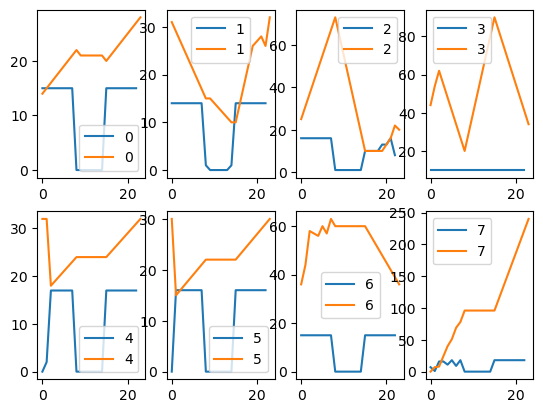

In [6]:
from ortools.linear_solver import pywraplp
UC=[0]+[5]*9+[25]*7+[5]*8
CAPA=[15,14,16,10,17,16,15,18]
SC=100 #setup cost
solver=pywraplp.Solver.CreateSolver('SAT')

#생산량 p[기계,시간]
p={}
for i in range(8):
    for j in range (1,25):
        p[i,j]=solver.NumVar(0,solver.infinity(),'p'+str(i)+'_'+str(j)) 
#재고량 
I={}
for i in range(8):
    for j in range(25):
        I[i,j]=solver.NumVar(0,solver.infinity(),'I'+str(i)+'_'+str(j))

#셋업비용 발생 여부
S={}
for i in range(8):
    for j in range(1,25):
        S[i,j]=solver.BoolVar('S'+str(i)+'_'+str(j))
#기계 가동 여부
Y={}
for i in range(8):
    for j in range(25):
        Y[i,j]=solver.BoolVar('Y'+str(i)+'_'+str(j))

#재고 제약
for i in range(7):
    for j in range(1,25):
        solver.Add( I[i,j] == I[i,(j-1)]+p[i,j]-p[(i+1),j])
for j in range(1,25):
    solver.Add(I[7,j]==I[7,(j-1)]+p[7,j])
for i in range(7):
    solver.Add(I[i,0]==2*CAPA[i+1])
solver.Add(I[7,0]==0)
for i in range(7):
    solver.Add(I[i,24]==2*CAPA[i+1])
solver.Add(I[7,24]==min(CAPA)*24)

#생산량 제약
#첫 기계는 재고에 의한 생산량 제약 없음
for i in range(1,8):
    for j in range(1,25):
        solver.Add(p[i,j]<=I[i-1,j-1])
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]<=CAPA[i]*Y[i,j])

#준비 비용 제약
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]>=Y[i,j])
for i in range(8):
    for j in range(2,25):
        solver.Add(S[i,j]>=Y[i,j]-Y[i,j-1])
for i in range(8):
    solver.Add(S[i,1]==Y[i,1])

#목적함수 
obj=[]
for i in range(8):
    for j in range(1,25):
        obj.append(UC[j]*p[i,j])
        obj.append(S[i,j]*100)
solver.Minimize(sum(obj))

status=solver.Solve()
p_data=[]
i_data=[]
if status==pywraplp.Solver.OPTIMAL or status==pywraplp.Solver.FEASIBLE:
    print(f'Total cost= {solver.Objective().Value()}')
    #그래프 그리기 위한 데이터 정리
    for i in range(8):
        temp=[]
        for j in range(1,25):
            temp.append(p[i,j].solution_value())
        p_data.append(temp)
    for i in range(8):
        temp=[]
        for j in range(25):
            temp.append(I[i,j].solution_value())
        i_data.append(temp)
    import matplotlib.pyplot as plt
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(p_data[i][1:],label=i)
        plt.legend()
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(i_data[i][1:],label=i)
        plt.legend()

실습 5-1(1)

In [8]:
from ortools.linear_solver import pywraplp
UC=[0]+[10]*24
CAPA=[15,14,16,10,17,16,15,18]
SC=100 #setup cost
solver=pywraplp.Solver.CreateSolver('SAT')

#생산량 p[기계,시간]
p={}
for i in range(8):
    for j in range (1,25):
        p[i,j]=solver.NumVar(0,solver.infinity(),'p'+str(i)+'_'+str(j)) 
#재고량 
I={}
for i in range(8):
    for j in range(25):
        I[i,j]=solver.NumVar(0,solver.infinity(),'I'+str(i)+'_'+str(j))

#셋업비용 발생 여부
S={}
for i in range(8):
    for j in range(1,25):
        S[i,j]=solver.BoolVar('S'+str(i)+'_'+str(j))
#기계 가동 여부
Y={}
for i in range(8):
    for j in range(25):
        Y[i,j]=solver.BoolVar('Y'+str(i)+'_'+str(j))

#재고 제약
for i in range(7):
    for j in range(1,25):
        solver.Add( I[i,j] == I[i,(j-1)]+p[i,j]-p[(i+1),j])
for j in range(1,25):
    solver.Add(I[7,j]==I[7,(j-1)]+p[7,j])
for i in range(7):
    solver.Add(I[i,0]==2*CAPA[i+1])
solver.Add(I[7,0]==0)
for i in range(7):
    solver.Add(I[i,24]==2*CAPA[i+1])
solver.Add(I[7,24]==min(CAPA)*24)

#생산량 제약
#첫 기계는 재고에 의한 생산량 제약 없음
for i in range(1,8):
    for j in range(1,25):
        solver.Add(p[i,j]<=I[i-1,j-1])
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]<=CAPA[i]*Y[i,j])

#준비 비용 제약
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]>=Y[i,j])
for i in range(8):
    for j in range(2,25):
        solver.Add(S[i,j]>=Y[i,j]-Y[i,j-1])
for i in range(8):
    solver.Add(S[i,1]==Y[i,1])

#목적함수 
obj=[]
for i in range(8):
    for j in range(1,25):
        obj.append(UC[j]*p[i,j])
        obj.append(S[i,j]*100)
solver.Minimize(sum(obj))

status=solver.Solve()
p_data=[]
i_data=[]
if status==pywraplp.Solver.OPTIMAL or status==pywraplp.Solver.FEASIBLE:
    print(f'Total cost= {solver.Objective().Value()}')

Total cost= 20000.0


실습 5-1(2) 

In [ ]:
from ortools.linear_solver import pywraplp
UC=[0]+[5]*10+[10]*2+[15]*4+[10]*4+[5]*4
UC1=[0]+[5]*10+[10]*2+[20]*4+[10]*4+[5]*4
UC2=[0]+[5]*10+[10]*2+[25]*4+[10]*4+[5]*4
CAPA=[15,14,16,10,17,16,15,18]
SC=100 #setup cost
solver=pywraplp.Solver.CreateSolver('SAT')

#생산량 p[기계,시간]
p={}
for i in range(8):
    for j in range (1,25):
        p[i,j]=solver.NumVar(0,solver.infinity(),'p'+str(i)+'_'+str(j)) 
#재고량 
I={}
for i in range(8):
    for j in range(25):
        I[i,j]=solver.NumVar(0,solver.infinity(),'I'+str(i)+'_'+str(j))

#셋업비용 발생 여부
S={}
for i in range(8):
    for j in range(1,25):
        S[i,j]=solver.BoolVar('S'+str(i)+'_'+str(j))
#기계 가동 여부
Y={}
for i in range(8):
    for j in range(25):
        Y[i,j]=solver.BoolVar('Y'+str(i)+'_'+str(j))

#재고 제약
for i in range(7):
    for j in range(1,25):
        solver.Add( I[i,j] == I[i,(j-1)]+p[i,j]-p[(i+1),j])
for j in range(1,25):
    solver.Add(I[7,j]==I[7,(j-1)]+p[7,j])
for i in range(7):
    solver.Add(I[i,0]==2*CAPA[i+1])
solver.Add(I[7,0]==0)
for i in range(7):
    solver.Add(I[i,24]==2*CAPA[i+1])
solver.Add(I[7,24]==min(CAPA)*24)

#생산량 제약
#첫 기계는 재고에 의한 생산량 제약 없음
for i in range(1,8):
    for j in range(1,25):
        solver.Add(p[i,j]<=I[i-1,j-1])
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]<=CAPA[i]*Y[i,j])

#준비 비용 제약
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]>=Y[i,j])
for i in range(8):
    for j in range(2,25):
        solver.Add(S[i,j]>=Y[i,j]-Y[i,j-1])
for i in range(8):
    solver.Add(S[i,1]==Y[i,1])

#목적함수 
obj=[]
obj1=[]
obj2=[]
for i in range(8):
    for j in range(1,25):
        obj.append(UC[j]*p[i,j])
        obj1.append(UC1[j]*p[i,j])
        obj2.append(UC2[j]*p[i,j])
        obj.append(S[i,j]*100)
        obj1.append(S[i,j]*100)
        obj2.append(S[i,j]*100)
solver.Minimize(sum(obj))
Cost=[]
status=solver.Solve()
if status==pywraplp.Solver.OPTIMAL or status==pywraplp.Solver.FEASIBLE:
    print(f'Total cost_UC1= {solver.Objective().Value()}')
    Cost.append(solver.Objective().Value())

solver.Minimize(sum(obj1))

status1=solver.Solve()
if status1==pywraplp.Solver.OPTIMAL or status==pywraplp.Solver.FEASIBLE:
    print(f'Total cost_UC2= {solver.Objective().Value()}')
    Cost.append(solver.Objective().Value())

solver.Minimize(sum(obj2))

status2=solver.Solve()
if status2==pywraplp.Solver.OPTIMAL or status==pywraplp.Solver.FEASIBLE:
    print(f'Total cost_UC3= {solver.Objective().Value()}')
    Cost.append(solver.Objective().Value())
print(f'Minimal Cost: {min(Cost)}')


   

Total cost_UC1= 12360.0
Total cost_UC2= 12700.0
Total cost_UC3= 13030.0
Minimal Cost: 12360.0


실습5-1 (3)

Total cost= 24940.0


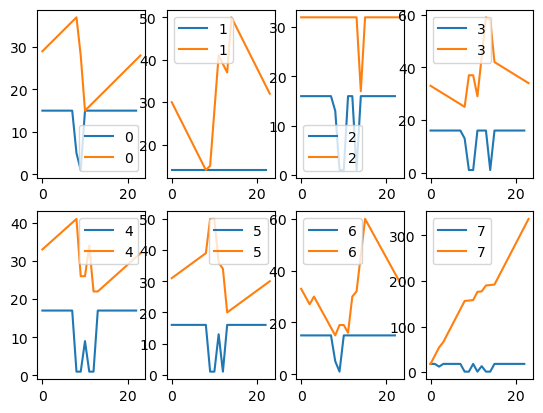

In [ ]:
from ortools.linear_solver import pywraplp
UC=[0]+[5]*9+[25]*7+[5]*8
CAPA=[15,14,16,16,17,16,15,18]
SC=100 #setup cost
solver=pywraplp.Solver.CreateSolver('SAT')

#생산량 p[기계,시간]
p={}
for i in range(8):
    for j in range (1,25):
        p[i,j]=solver.NumVar(0,solver.infinity(),'p'+str(i)+'_'+str(j)) 
#재고량 
I={}
for i in range(8):
    for j in range(25):
        I[i,j]=solver.NumVar(0,solver.infinity(),'I'+str(i)+'_'+str(j))

#셋업비용 발생 여부
S={}
for i in range(8):
    for j in range(1,25):
        S[i,j]=solver.BoolVar('S'+str(i)+'_'+str(j))
#기계 가동 여부
Y={}
for i in range(8):
    for j in range(25):
        Y[i,j]=solver.BoolVar('Y'+str(i)+'_'+str(j))

#재고 제약
for i in range(7):
    for j in range(1,25):
        solver.Add( I[i,j] == I[i,(j-1)]+p[i,j]-p[(i+1),j])
for j in range(1,25):
    solver.Add(I[7,j]==I[7,(j-1)]+p[7,j])
for i in range(7):
    solver.Add(I[i,0]==2*CAPA[i+1])
solver.Add(I[7,0]==0)
for i in range(7):
    solver.Add(I[i,24]==2*CAPA[i+1])
solver.Add(I[7,24]==min(CAPA)*24)

#생산량 제약
#첫 기계는 재고에 의한 생산량 제약 없음
for i in range(1,8):
    for j in range(1,25):
        solver.Add(p[i,j]<=I[i-1,j-1])
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]<=CAPA[i]*Y[i,j])

#준비 비용 제약
for i in range(8):
    for j in range(1,25):
        solver.Add(p[i,j]>=Y[i,j])
for i in range(8):
    for j in range(2,25):
        solver.Add(S[i,j]>=Y[i,j]-Y[i,j-1])
for i in range(8):
    solver.Add(S[i,1]==Y[i,1])

#목적함수 
obj=[]
for i in range(8):
    for j in range(1,25):
        obj.append(UC[j]*p[i,j])
        obj.append(S[i,j]*100)
solver.Minimize(sum(obj))

status=solver.Solve()
p_data=[]
i_data=[]
if status==pywraplp.Solver.OPTIMAL or status==pywraplp.Solver.FEASIBLE:
    print(f'Total cost= {solver.Objective().Value()}')
    #그래프 그리기 위한 데이터 정리
    for i in range(8):
        temp=[]
        for j in range(1,25):
            temp.append(p[i,j].solution_value())
        p_data.append(temp)
    for i in range(8):
        temp=[]
        for j in range(25):
            temp.append(I[i,j].solution_value())
        i_data.append(temp)
    import matplotlib.pyplot as plt
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(p_data[i][1:],label=i)
        plt.legend()
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(i_data[i][1:],label=i)
        plt.legend()

실습5-1 

P[0, 1] = 12
P[0, 2] = 12
P[0, 3] = 12
P[0, 4] = 12
P[0, 5] = 12
P[0, 6] = 12
P[0, 7] = 1
P[0, 8] = 1
P[0, 9] = 9
P[0, 10] = 1
P[0, 11] = 1
P[0, 12] = 1
P[0, 13] = 1
P[0, 14] = 1
P[0, 15] = 1
P[0, 16] = 1
P[0, 17] = 1
P[0, 18] = 1
P[0, 19] = 1
P[0, 20] = 1
P[0, 21] = 1
P[0, 22] = 1
P[0, 23] = 12
P[0, 24] = 12
P[1, 1] = 8
P[1, 2] = 8
P[1, 3] = 8
P[1, 4] = 8
P[1, 5] = 8
P[1, 6] = 8
P[1, 7] = 8
P[1, 8] = 8
P[1, 9] = 8
P[1, 10] = 1
P[1, 11] = 1
P[1, 12] = 1
P[1, 13] = 1
P[1, 14] = 1
P[1, 15] = 1
P[1, 16] = 1
P[1, 17] = 1
P[1, 18] = 1
P[1, 19] = 1
P[1, 20] = 8
P[1, 21] = 6
P[1, 22] = 8
P[1, 23] = 8
P[1, 24] = 8
P[2, 1] = 15
P[2, 2] = 15
P[2, 3] = 15
P[2, 4] = 15
P[2, 5] = 15
P[2, 6] = 15
P[2, 7] = 15
P[2, 8] = 1
P[2, 9] = 14
P[3, 1] = 5
P[3, 2] = 5
P[3, 3] = 5
P[3, 4] = 5
P[3, 5] = 5
P[3, 6] = 5
P[3, 7] = 5
P[3, 8] = 5
P[3, 9] = 5
P[3, 10] = 5
P[3, 11] = 5
P[3, 12] = 5
P[3, 13] = 5
P[3, 14] = 5
P[3, 15] = 5
P[3, 16] = 5
P[3, 17] = 5
P[3, 18] = 5
P[3, 19] = 5
P[3, 20] = 5
P[3, 21] = 5
P[3, 2

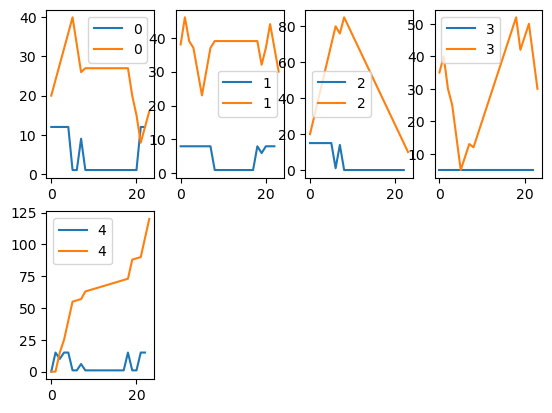

In [38]:

from ortools.linear_solver import pywraplp

UC = [0] + [5]*6 + [10]*3 + [15]*4 + [25]*3 + [15]*3 + [10]*3 + [5]*2

CAPA = [12, 8, 15, 5, 15]
SC = 100 # setup cost

nMach = len(CAPA)

solver = pywraplp.Solver.CreateSolver("SAT")

# 생산량
P = {}
for i in range(nMach):
    for j in range(1, 25):
        P[i, j] = solver.NumVar(0, solver.infinity(), "P"+str(i)+'_'+str(j))

# 재고량
I = {}
for i in range(nMach):
    for j in range(25):
        I[i, j] = solver.NumVar(0, solver.infinity(), "I"+str(i)+'_'+str(j))
        
# 셋업비용 발생여부
S = {}
for i in range(nMach):
    for j in range(1, 25):
        S[i, j] = solver.IntVar(0, 1, "S"+str(i)+'_'+str(j))

# 기계 가동 여부
Y = {}
for i in range(nMach):
    for j in range(1, 25):
        Y[i, j] = solver.IntVar(0, 1, "Y"+str(i)+'_'+str(j))  

######### 재고제약 
# 기계 0 - 3
i = 0
for j in range(1,25):
    solver.Add(I[i,j] - I[i,j-1] - P[i,j] + P[i+1,j] == 0, 'Inv_'+str(i)+str(j))

i = 1
for j in range(1,25):
    solver.Add(I[i,j] - I[i,j-1] - P[i,j] + P[4,j] == 0, 'Inv_'+str(i)+str(j))

i = 2
for j in range(1,25):
    solver.Add(I[i,j] - I[i,j-1] - P[i,j] + P[i+1,j] == 0, 'Inv_'+str(i)+str(j))
    
i = 3
for j in range(1,25):
    solver.Add(I[i,j] - I[i,j-1] - P[i,j] + P[4,j] == 0, 'Inv_'+str(i)+str(j))

# 재고제약 기계 4
for j in range(1,25):
        solver.Add(I[4,j] - I[4,j-1] - P[4,j] == 0, 'Inv_4'+str(j)) 
            
######### 초기재고
# 기계 0-3
solver.Add(I[0,0] - 2 * CAPA[1] == 0,'init_inv_0_0')
solver.Add(I[1,0] - 2 * CAPA[4] == 0,'init_inv_1_0')
solver.Add(I[2,0] - 2 * CAPA[3] == 0,'init_inv_2_0')
solver.Add(I[3,0] - 2 * CAPA[4] == 0,'init_inv_3_0')

#기계 4 초기 재고

solver.Add(I[4,0] == 0, 'init_inv_4_0')

###### 기말재고
# 기계 0-3
solver.Add(I[0,24] - 2 * CAPA[1] == 0,'last_inv_0_0')
solver.Add(I[1,24] - 2 * CAPA[4] == 0,'last_inv_1_0')
solver.Add(I[2,24] - 2 * CAPA[3] == 0,'last_inv_2_0')
solver.Add(I[3,24] - 2 * CAPA[4] == 0,'last_inv_3_0')

# 기계 4 (= Throughput)
solver.Add(I[4, 24] == 120, 'last_inv_4_24')
    
# 재고에 의한 생산량 제약
# 기계 0과 1은 재고에 의한 생산 제약이 없음.
for i in [1, 3, 4]:
    for j in range(1, 25):
        solver.Add(P[i,j] - I[i-1,j-1] <= 0, 'prod_inv_'+str(i)+str(j))

i = 4
for j in range(1, 25):
    solver.Add(P[i,j] - I[1,j-1] <= 0, 'prod_inv_1_'+str(i)+str(j))
    solver.Add(P[i,j] - I[3,j-1] <= 0, 'prod_inv_3_'+str(i)+str(j))

# 생산용량에 의한 제약 - 가동여부
for i in range(5):
    for j in range(1, 25):
        solver.Add(P[i,j] - CAPA[i] * Y[i,j] <= 0, 'prod_capa_'+str(i)+str(j))

for i in range(5):
    for j in range(1, 25):
        solver.Add(P[i,j] - Y[i,j] >= 0, 'prod_capa2_'+str(i)+str(j))

# 준비비용 발생 여부       
for i in range(5):
    for j in range(2, 25):
        solver.Add(S[i,j] - Y[i,j] + Y[i,j-1] >= 0, 'setup_cost_'+str(i)+str(j)) 
        
# 첫 기간에 대한 준비 비용 발생여부
for i in range(5):
    solver.Add(S[i,1] - Y[i,1] == 0, 'setup_cost_'+str(i)+'1') 
    
# Objective
objective_terms = []
for i in range(5):
    for j in range(1,25):
        objective_terms.append(UC[j] * P[i,j] + SC * S[i,j])
        #if i != 7 and j != 24:
        #    objective_terms.append(IC * I[i,j])

solver.Minimize(solver.Sum(objective_terms))

if 1:
    with open('or12-3.lp', "w") as out_f:
        lp_text = solver.ExportModelAsLpFormat(False)
        out_f.write(lp_text)

# Solve
status = solver.Solve()

p_data = []
i_data = []
DEBUG = 0
# Print solution.
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:

    # 그래프 그리기 위한 데이터 정리
    for i in range(5):
        temp = []
        for j in range(1, 25):
            temp.append(P[i, j].solution_value())
        p_data.append(temp)

    for i in range(5):
        temp = []
        for j in range(25):
            temp.append(I[i, j].solution_value())
        i_data.append(temp)
        
    
    if DEBUG == 0:
        for i in range(5):
            for j in range(1, 25):
                if P[i, j].solution_value() > 0.5:
                    print("P[%d, %d] = %d" %(i, j, P[i, j].solution_value()))
    elif DEBUG == 1:
        for i in range(5):
            for j in range(25):
                if I[i, j].solution_value() > 0.5:
                    print("I[%d, %d] = %d" %(i, j, I[i, j].solution_value()))
    else:
        for i in range(5):
            for j in range(1, 25):
                if Y[i, j].solution_value() > 0.5:
                    print("Y[%d, %d] = %d" %(i, j, Y[i, j].solution_value()))
                    print("S[%d, %d] = %d" %(i, j, S[i, j].solution_value()))
                    
    print(f"Total cost = {solver.Objective().Value():.1f}\n", )
    
    import matplotlib.pyplot as plt

    for i in range(5):
        plt.subplot(2, 4, i+1)
        plt.plot(p_data[i][1:], label = i)
        plt.legend()
        
    for i in range(5):
        plt.subplot(2, 4, i+1)
        plt.plot(i_data[i][1:], label=i)
        plt.legend()
    
else:
    print("No solution found.")


